Logistic Regression accuracy: 0.9111111111111111

Classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45


Plotting decision boundaries (using first 2 features)...


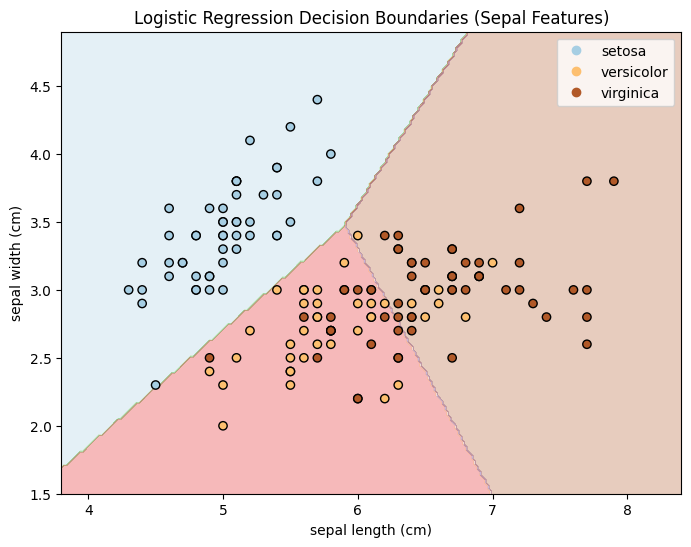

In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
import numpy as np

def classification_demo_logistic():
    """
    Logistic Regression demo on Iris dataset.
    """
    # 1. Load Data
    iris = load_iris()
    X = iris.data
    y = iris.target
    target_names = iris.target_names
    feature_names = iris.feature_names

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

    # 2. Scale Features (Helps optimization converge faster)
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    # 3. Train Model (All Features)
    logreg = LogisticRegression(max_iter=200)
    logreg.fit(X_train_s, y_train)

    # 4. Predict
    y_pred = logreg.predict(X_test_s)

    # 5. Evaluate
    print("Logistic Regression accuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification report:")
    print(classification_report(y_test, y_pred, target_names=target_names))

    # 6. Visualization (2D Projection)
    print("\nPlotting decision boundaries (using first 2 features)...")

    # Retrain on just the first two features for 2D plotting
    X_2d = X[:, :2]  # Sepal length, Sepal width

    # Train simplified model for visualization
    logreg_2d = LogisticRegression(max_iter=200)
    logreg_2d.fit(X_2d, y)

    # Create plotting meshgrid
    x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
    y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
    h = 0.02  # Step size
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    # Predict for each point in meshgrid
    Z = logreg_2d.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Paired)
    scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, edgecolors='k', cmap=plt.cm.Paired)

    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])
    plt.title('Logistic Regression Decision Boundaries (Sepal Features)')
    plt.legend(handles=scatter.legend_elements()[0], labels=list(target_names))
    plt.show()


classification_demo_logistic()